# Counterfactual GRPO vs Vanilla GRPO on GSM8K

**Counterfactual GRPO** applies per-token importance weighting to the GRPO objective. It identifies critical reasoning spans (arithmetic, answer regions) via counterfactual masking and upweights their gradient contribution.

**Setup:**
- Model: `Qwen/Qwen3-1.7B` with LoRA (r=32)
- Dataset: GSM8K train split (7,473 problems)
- Reward: math correctness (binary)
- G=8 generations per prompt, 300 steps
- Batch size 16, gradient accumulation 1, lr=1.5e-5
- Checkpoints saved every 50 steps (6 checkpoints)
- Evaluation: GSM8K test set (1,319 problems) at each checkpoint

In [1]:
import os, gc, json, sys, subprocess
import torch

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('/home/jovyan/Finetunehub')

MODEL_NAME = 'Qwen/Qwen3-1.7B'

TRAIN_KWARGS = dict(
    model_name=MODEL_NAME,
    dataset_name='openai/gsm8k',
    config_name='main',
    column_mapping={'question': 'prompt', 'answer': 'response'},
    system_prompt='You are a careful math tutor. Solve step by step and provide the final numeric answer.',
    backend='trl',
    num_epochs=1,
    max_steps=300,
    batch_size=16,
    learning_rate=1.5e-5,
    gradient_accumulation_steps=1,
    max_prompt_length=256,
    max_completion_length=768,
    temperature=0.6,
    top_p=0.95,
    num_generations=8,
    beta=0.01,
    use_peft=True,
    lora_r=32,
    lora_alpha=32,
    lora_dropout=0.1,
    lora_target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                         'gate_proj', 'up_proj', 'down_proj'],
    bf16=True,
    loss_type='dapo',
    max_seq_length=1024,
    rewards=[{'type': 'math_correctness', 'weight': 1.0, 'params': {}}],
    save_steps=50,
    save_total_limit=10,
    logging_steps=10,
    seed=42,
    data_seed=47,
    max_grad_norm=1.0,
)

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()

print('Setup complete.')

Setup complete.


## 1. Train Counterfactual GRPO

In [3]:
from aligntune.core.backend_factory import create_rl_trainer

CF_DIR = './output/nb_counterfact_grpo'

trainer = create_rl_trainer(
    algorithm='counterfact_grpo',
    output_dir=CF_DIR,
    boost_factor=2.0,
    min_weight=0.15,
    answer_weight=1.5,
    enable_gradient_conservation=False,
    weight_debug=True,
    weighting_mode='counterfactual',
    **TRAIN_KWARGS,
)

print('Starting Counterfactual GRPO training...')
cf_results = trainer.train()
print(f'Training complete: {cf_results.get("total_steps", "?")} steps')
print(f'Model saved to: {CF_DIR}')

del trainer
cleanup()

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Starting Counterfactual GRPO training...

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 34,865,152 || all params: 1,755,440,128 || trainable%: 1.9861

...

  Advantage std: 0.000000 - all samples have same reward

  Samples processed: 600

  Optimization stats: {'cache_hits': 8, 'cache_misses': 2120, 'skipped_uniform': 2710}

Training complete: 300 steps

Model saved to: ./output/nb_counterfact_grpo

## 2. Train Vanilla GRPO

In [3]:
VAN_DIR = './output/nb_vanilla_grpo'

trainer = create_rl_trainer(
    algorithm='grpo',
    output_dir=VAN_DIR,
    **TRAIN_KWARGS,
)

print('Starting Vanilla GRPO training...')
van_results = trainer.train()
print(f'Training complete: {van_results.get("total_steps", "?")} steps')
print(f'Model saved to: {VAN_DIR}')

del trainer
cleanup()

Starting Vanilla GRPO training...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 34,865,152 || all params: 1,755,440,128 || trainable%: 1.9861

Processing train split (7473 examples)

Final columns: ['prompt', 'response']

...

Reward stats: min=0.50, max=1.00, mean=0.66

BATCH REWARDS: 16 passed | 0 partial | 0 failed | total=16

Reward stats: min=1.00, max=1.00, mean=1.00

Training complete: 300 steps

Model saved to: ./output/nb_vanilla_grpo

## 3. Evaluate on GSM8K

In [7]:
VLLM_PYTHON = '/home/jovyan/Finetunehub/.venv/bin/python'
SAVE_STEPS = TRAIN_KWARGS['save_steps']
MAX_STEPS = TRAIN_KWARGS['max_steps']
CHECKPOINTS = list(range(SAVE_STEPS, MAX_STEPS + 1, SAVE_STEPS))

eval_results = {}  # {label: {step: accuracy}}

# Eval base model
base_out = './eval_results/nb_gsm8k_base'
base_file = f'{base_out}/results.json'
if os.path.exists(base_file):
    with open(base_file) as f:
        r = json.load(f)
    base_acc = r['accuracy']
    print(f'Base: {base_acc:.2%} (cached)')
else:
    print('Evaluating Base...', flush=True)
    cmd = [VLLM_PYTHON, 'eval_gsm8k.py',
           '--model_path', MODEL_NAME,
           '--output_dir', base_out,
           '--temperature', '0.0', '--max_tokens', '2048']
    env = {**os.environ, 'CUDA_VISIBLE_DEVICES': '0'}
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=1800, env=env)
    if proc.returncode != 0:
        print(f'  ERROR: {proc.stderr[-500:]}')
        base_acc = 0
    else:
        with open(base_file) as f:
            r = json.load(f)
        base_acc = r['accuracy']
        print(f'Base: {base_acc:.2%} ({r["correct"]}/{r["total"]})')
    cleanup()

# Eval each checkpoint for both methods
for method, out_dir_base, eval_prefix in [
    ('Vanilla GRPO', VAN_DIR, 'nb_gsm8k_vanilla'),
    ('Counterfactual GRPO', CF_DIR, 'nb_gsm8k_counterfact'),
]:
    eval_results[method] = {}
    for step in CHECKPOINTS:
        lora_path = f'{out_dir_base}/checkpoint-{step}'
        if not os.path.exists(lora_path):
            print(f'{method} step {step}: checkpoint missing, skipping')
            continue
        out_dir = f'./eval_results/{eval_prefix}_cp{step}'
        results_file = f'{out_dir}/results.json'

        if os.path.exists(results_file):
            with open(results_file) as f:
                r = json.load(f)
            eval_results[method][step] = r['accuracy']
            print(f'{method} step {step}: {r["accuracy"]:.2%} (cached)')
            continue

        print(f'Evaluating {method} step {step}...', flush=True)
        cmd = [VLLM_PYTHON, 'eval_gsm8k.py',
               '--model_path', MODEL_NAME,
               '--lora_path', lora_path,
               '--output_dir', out_dir,
               '--temperature', '0.0', '--max_tokens', '2048']
        env = {**os.environ, 'CUDA_VISIBLE_DEVICES': '0'}
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=1800, env=env)
        if proc.returncode != 0:
            print(f'  ERROR: {proc.stderr[-500:]}')
            continue

        with open(results_file) as f:
            r = json.load(f)
        eval_results[method][step] = r['accuracy']
        print(f'{method} step {step}: {r["accuracy"]:.2%} ({r["correct"]}/{r["total"]})')
        cleanup()

print(f'\nAll evaluations complete. Base: {base_acc:.2%}')

Base: 78.47% (cached)

Vanilla GRPO step 50: 79.53% (cached)

Vanilla GRPO step 100: 79.98% (cached)

Vanilla GRPO step 150: 80.14% (cached)

Vanilla GRPO step 200: 80.21% (cached)

...

Evaluating Counterfactual GRPO step 250...

Counterfactual GRPO step 250: 80.06% (1056/1319)

Evaluating Counterfactual GRPO step 300...

Counterfactual GRPO step 300: 79.83% (1053/1319)


All evaluations complete. Base: 78.47%

## 4. Eval Curves & Results

In [9]:
print('=' * 70)
print(f'{"Step":<8}', end='')
for method in eval_results:
    print(f'{method:>20}', end='')
print()
print('-' * 70)
print(f'{"Base":<8}', end='')
for method in eval_results:
    print(f'{base_acc:>20.2%}', end='')
print()
for step in CHECKPOINTS:
    print(f'{step:<8}', end='')
    for method in eval_results:
        acc = eval_results[method].get(step)
        if acc is not None:
            diff = acc - base_acc
            print(f'{acc:>12.2%} ({diff:+.1%})', end='')
        else:
            print(f'{"—":>20}', end='')
    print()
print('=' * 70)

# Best per method
print('\nBest checkpoint:')
for method, accs in eval_results.items():
    if accs:
        best_step = max(accs, key=accs.get)
        print(f'  {method}: step {best_step} = {accs[best_step]:.2%} ({accs[best_step] - base_acc:+.2%} vs base)')

Step    

        Vanilla GRPO

 Counterfactual GRPO

----------------------------------------------------------------------

Base    

...

      79.83% (+1.4%)

      79.83% (+1.4%)


Best checkpoint:

  Vanilla GRPO: step 200 = 80.21% (+1.74% vs base)

  Counterfactual GRPO: step 150 = 80.52% (+2.05% vs base)

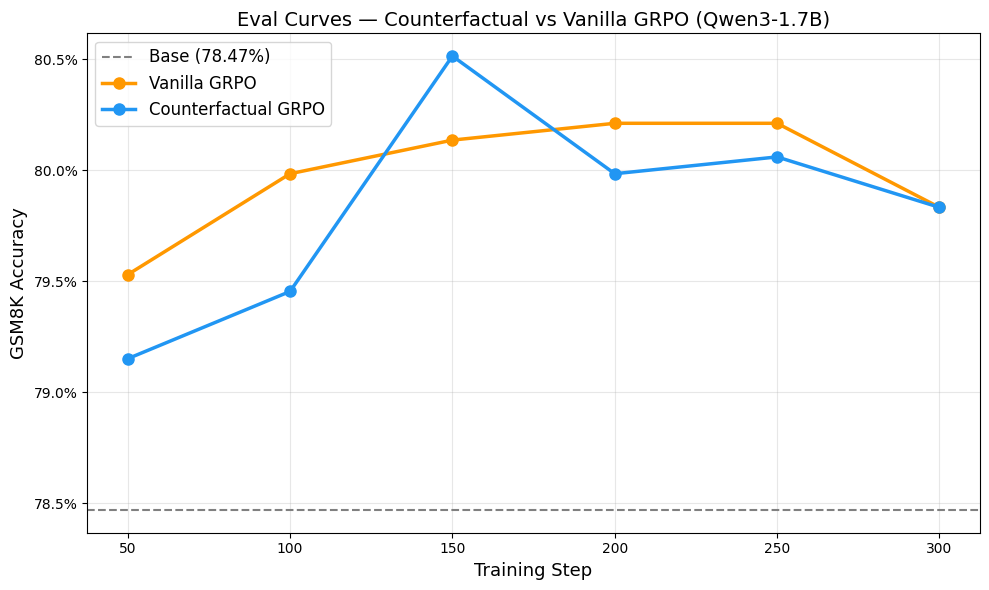

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 6))

ax.axhline(base_acc, color='gray', linestyle='--', linewidth=1.5,
           label=f'Base ({base_acc:.2%})')

colors_q3 = {'Vanilla GRPO': '#FF9800', 'Counterfactual GRPO': '#2196F3'}
for method, accs in eval_results.items():
    if not accs:
        continue
    steps = sorted(accs.keys())
    vals = [accs[s] for s in steps]
    ax.plot(steps, vals, 'o-', color=colors_q3[method], linewidth=2.5,
            markersize=8, label=method)

ax.set_xlabel('Training Step', fontsize=13)
ax.set_ylabel('GSM8K Accuracy', fontsize=13)
ax.set_title('Eval Curves — Counterfactual vs Vanilla GRPO (Qwen3-1.7B)', fontsize=14)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/counterfact_eval_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Training Dynamics

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

def load_logs(output_dir):
    cps = sorted(Path(output_dir).glob('checkpoint-*'),
                 key=lambda p: int(p.name.split('-')[1]))
    if not cps:
        return []
    with open(cps[-1] / 'trainer_state.json') as f:
        return json.load(f)['log_history']

def extract(logs, key):
    s, v = [], []
    for e in logs:
        if key in e:
            s.append(e['step'])
            v.append(e[key])
    return np.array(s), np.array(v)

cf_logs = load_logs(CF_DIR)
van_logs = load_logs(VAN_DIR)

print(f'Counterfactual: {len(cf_logs)} log entries')
print(f'Vanilla: {len(van_logs)} log entries')

Counterfactual: 30 log entries

Vanilla: 30 log entries

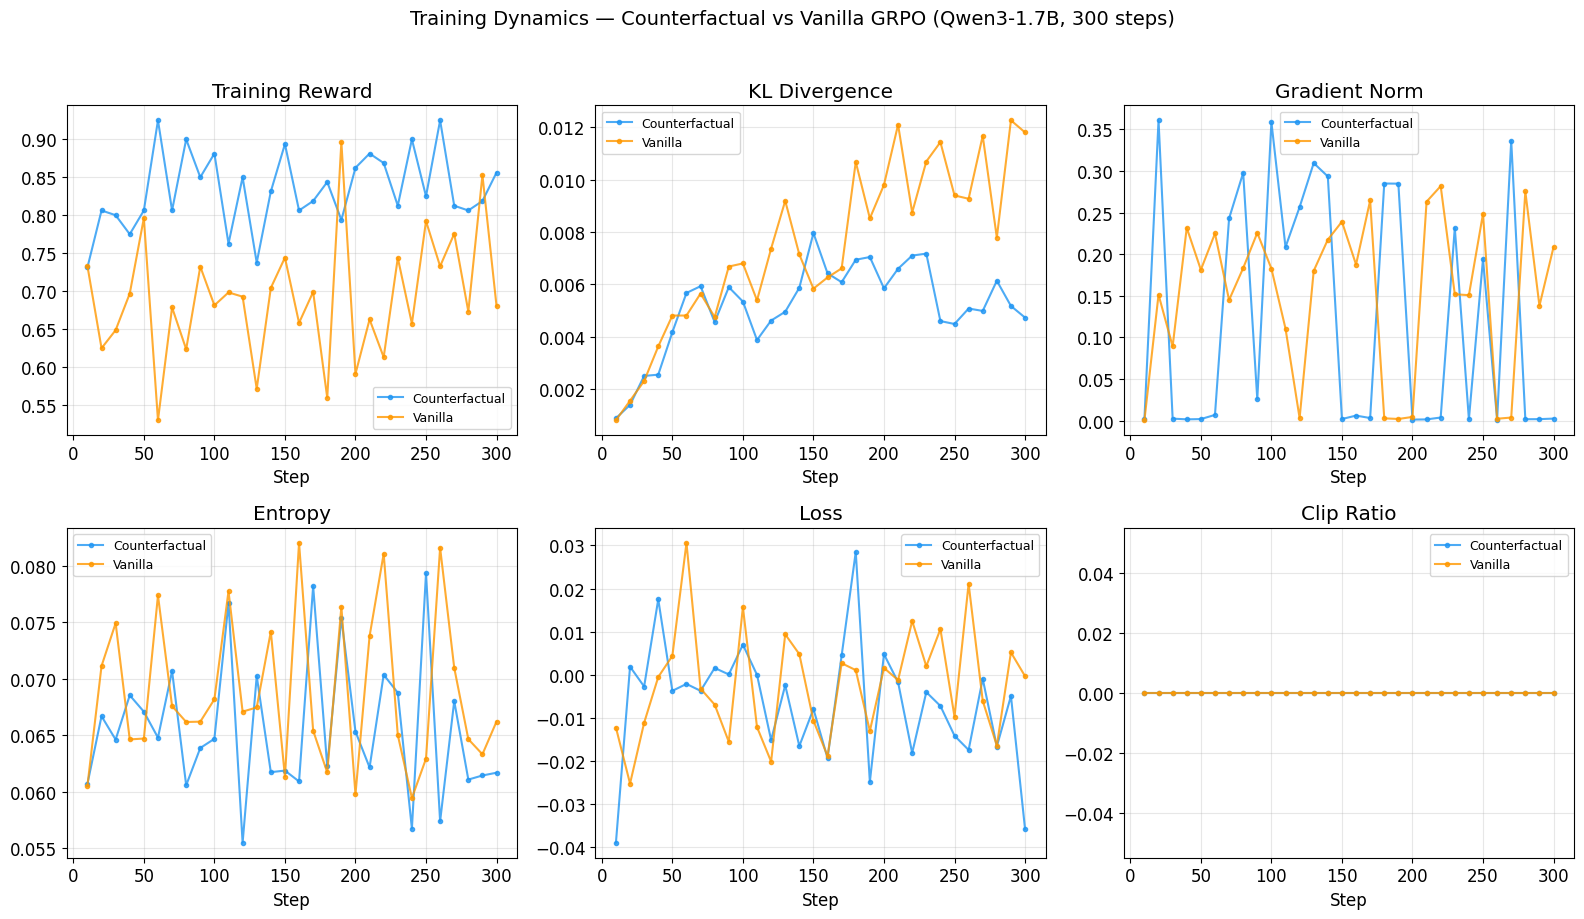

In [13]:
metrics = [
    ('reward', 'Training Reward'),
    ('kl', 'KL Divergence'),
    ('grad_norm', 'Gradient Norm'),
    ('entropy', 'Entropy'),
    ('loss', 'Loss'),
    ('clip_ratio/region_mean', 'Clip Ratio'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (key, title) in zip(axes, metrics):
    for logs, label, color in [
        (cf_logs, 'Counterfactual', '#2196F3'),
        (van_logs, 'Vanilla', '#FF9800'),
    ]:
        s, v = extract(logs, key)
        if len(s) > 0:
            ax.plot(s, v, 'o-', color=color, linewidth=1.5, markersize=3,
                    alpha=0.8, label=label)
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.legend(fontsize=9)

fig.suptitle('Training Dynamics — Counterfactual vs Vanilla GRPO (Qwen3-1.7B, 300 steps)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/counterfact_training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Counterfactual Importance Weights

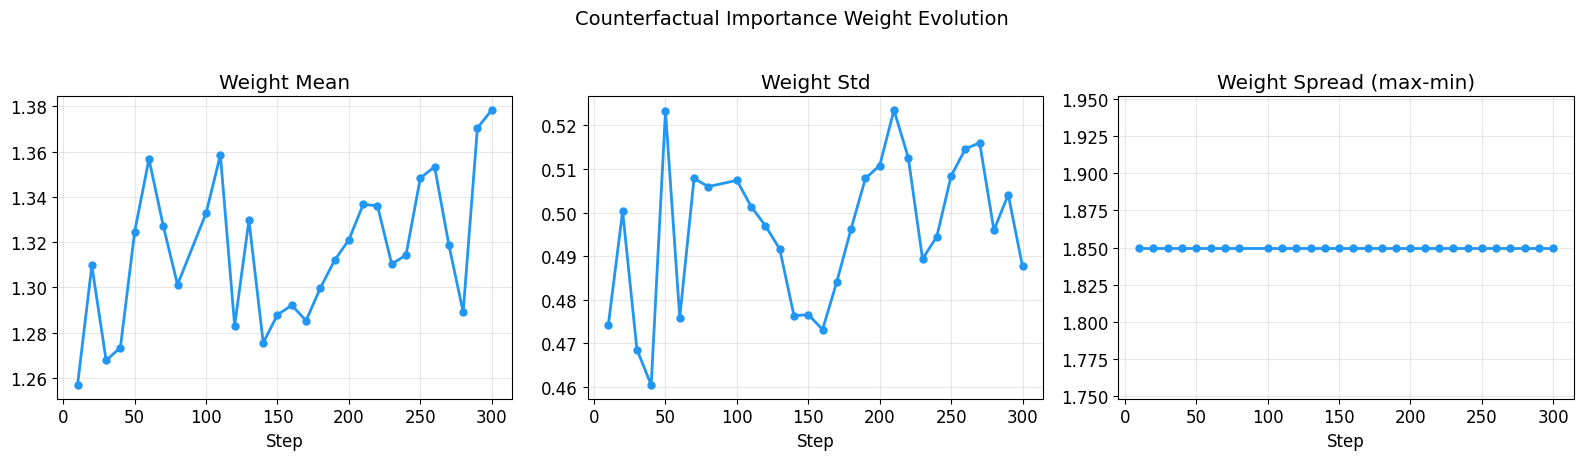

In [15]:
cf_weight_keys = [
    ('counterfact/weight_mean', 'Weight Mean'),
    ('counterfact/weight_std', 'Weight Std'),
    ('counterfact/weight_spread', 'Weight Spread (max-min)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (key, title) in zip(axes, cf_weight_keys):
    s, v = extract(cf_logs, key)
    if len(s) > 0:
        ax.plot(s, v, 'o-', color='#2196F3', linewidth=2, markersize=5)
    ax.set_title(title)
    ax.set_xlabel('Step')

fig.suptitle('Counterfactual Importance Weight Evolution',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/counterfact_weight_evolution.png', dpi=150, bbox_inches='tight')
plt.show()